# Battery Capacity Prediction — Regression Analysis

**Dataset:** NASA Li-ion battery ageing dataset (cleaned discharge cycles)

**Task type:** Regression


# Environment setup

All libraries used anywhere in the notebook are imported 

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# --- model selection / preprocessing ---
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.pipeline import Pipeline

# --- regression models (10) ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# --- metrics ---
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

RANDOM_STATE = 42
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


##  Dataset loading and audit


In [12]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "data" / "nasa"

METADATA_PATH = DATASET_DIR / "metadata.csv"
DATA_DIR = DATASET_DIR / "data"

print("Project folder :", PROJECT_ROOT)
print("Dataset folder :", DATASET_DIR)
print("Metadata exists:", METADATA_PATH.exists())
print("Data folder exists:", DATA_DIR.exists())

Project folder : C:\Users\kolus\ML_Project
Dataset folder : C:\Users\kolus\ML_Project\data\nasa
Metadata exists: True
Data folder exists: False


In [13]:
metadata = pd.read_csv(METADATA_PATH)
metadata.columns = metadata.columns.str.strip()

print("Dataset shape:", metadata.shape)
print("\nColumn names:")
print(metadata.columns.tolist())

print("\nFirst 5 rows:")
display(metadata.head())

Dataset shape: (7565, 10)

Column names:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

First 5 rows:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [14]:
print("Dataset Information")
print("=" * 60)
metadata.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [15]:
print("Statistical summary (all columns)")
display(metadata.describe(include="all").T)

Statistical summary (all columns)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type,7565,3,charge,2815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_time,7565,2494,[2010. 7. 21. 15. 0. ...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ambient_temperature,7565.0,NaN,NaN,NaN,20.017713,11.082914,4.0,4.0,24.0,24.0,44.0
battery_id,7565,34,B0006,616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test_id,7565.0,NaN,NaN,NaN,176.012558,152.174147,0.0,55.0,129.0,255.0,615.0
uid,7565.0,NaN,NaN,NaN,3783.0,2183.971726,1.0,1892.0,3783.0,5674.0,7565.0
filename,7565,7565,00001.csv,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Capacity,2794,2752,[],25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Re,1956,1956,0.05605783343888099,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rct,1956,1956,0.20097016584458333,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
missing_values = metadata.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing %": (missing_values.values / len(metadata) * 100).round(2)
}).sort_values(by="Missing Values", ascending=False)

print("Missing-value audit of metadata:")
display(missing_table)

Missing-value audit of metadata:


,Column,Missing Values,Missing %
9,Rct,5609,74.14
8,Re,5609,74.14
7,Capacity,4771,63.07
0,type,0,0.00
1,start_time,0,0.00
2,ambient_temperature,0,0.00
5,uid,0,0.00
4,test_id,0,0.00
3,battery_id,0,0.00
6,filename,0,0.00


In [17]:
print("Experiment types present in the metadata:")
print(metadata["type"].value_counts())

Experiment types present in the metadata:
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64


In [18]:
discharge_data = metadata[
    metadata["type"].astype(str).str.lower() == "discharge"
].copy()

discharge_data["Capacity"] = pd.to_numeric(discharge_data["Capacity"], errors="coerce")

print("Total discharge records:", len(discharge_data))
print("\nTarget (Capacity) distribution:")
print(discharge_data["Capacity"].describe())

display(discharge_data.head())

Total discharge records: 2794

Target (Capacity) distribution:
count    2769.000000
mean        1.326543
std         0.472517
min         0.000000
25%         1.150286
50%         1.428065
75%         1.673645
max         2.640149
Name: Capacity, dtype: float64


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,NaN,NaN


## Feature extraction from raw cycle files

In [19]:
def extract_features(csv_path):
    """Summarise one raw discharge-cycle time series into a fixed feature vector."""

    df = pd.read_csv(csv_path)

    voltage = pd.to_numeric(df["Voltage_measured"], errors="coerce")
    current = pd.to_numeric(df["Current_measured"], errors="coerce")
    temperature = pd.to_numeric(df["Temperature_measured"], errors="coerce")
    time = pd.to_numeric(df["Time"], errors="coerce")

    features = {}

    # Voltage features
    features["mean_voltage"] = voltage.mean()
    features["min_voltage"] = voltage.min()
    features["max_voltage"] = voltage.max()
    features["voltage_std"] = voltage.std()

    # Current features
    features["mean_current"] = current.mean()
    features["max_current"] = current.max()
    features["min_current"] = current.min()

    # Temperature features
    features["mean_temperature"] = temperature.mean()
    features["max_temperature"] = temperature.max()
    features["min_temperature"] = temperature.min()
    features["temperature_std"] = temperature.std()

    # Engineered time features
    features["discharge_duration"] = time.max() - time.min()
    features["voltage_drop"] = voltage.max() - voltage.min()
    features["temperature_rise"] = temperature.max() - temperature.min()

    # Approximate delivered charge (integral of |current| dt), in Ah.
    # NumPy 2.0 renamed np.trapz -> np.trapezoid, so pick whichever exists.
    trapezoid = getattr(np, "trapezoid", None) or np.trapz

    features["charge_throughput"] = trapezoid(
        np.abs(current.fillna(0).values),
        time.fillna(0).values
    ) / 3600.0

    # Number of measurements in the cycle
    features["sample_count"] = len(df)

    return features


print("Feature extraction function defined.")

Feature extraction function defined.


In [20]:
feature_rows = []
errors = []
missing_files = 0

print("Extracting features from raw cycle files...")

for index, row in discharge_data.iterrows():

    filename = str(row["filename"])
    file_path = DATA_DIR / filename

    if not file_path.exists():
        missing_files += 1
        continue

    try:
        features = extract_features(file_path)

        features["battery_id"] = row["battery_id"]
        features["capacity"] = row["Capacity"]

        if "ambient_temperature" in row:
            features["ambient_temperature"] = row["ambient_temperature"]

        feature_rows.append(features)

    except Exception as e:
        errors.append((filename, f"{type(e).__name__}: {e}"))

print("Feature extraction completed.")
print("  Cycles processed :", len(feature_rows))
print("  Files not found  :", missing_files)
print("  Failed to parse  :", len(errors))

# Show only the first few distinct errors instead of one line per file
if errors:
    distinct = sorted({message for _, message in errors})[:5]
    print("Distinct error messages (first 5):")
    for message in distinct:
        print("   -", message)

if not feature_rows:
    raise RuntimeError(
        "No features were extracted. Check DATA_DIR and the error messages above."
    )

Extracting features from raw cycle files...
Feature extraction completed.
  Cycles processed : 2794
  Files not found  : 0
  Failed to parse  : 0


In [21]:
battery_df = pd.DataFrame(feature_rows)

print("Final ML dataset shape:", battery_df.shape)
print("\nData types:")
print(battery_df.dtypes)
print("\nMissing values per column:")
print(battery_df.isnull().sum())

display(battery_df.head())

Final ML dataset shape: (2794, 19)

Data types:
mean_voltage           float64
min_voltage            float64
max_voltage            float64
voltage_std            float64
mean_current           float64
max_current            float64
min_current            float64
mean_temperature       float64
max_temperature        float64
min_temperature        float64
temperature_std        float64
discharge_duration     float64
voltage_drop           float64
temperature_rise       float64
charge_throughput      float64
sample_count             int64
battery_id                 str
capacity               float64
ambient_temperature      int64
dtype: object

Missing values per column:
mean_voltage            0
min_voltage             0
max_voltage             0
voltage_std             0
mean_current            0
max_current             0
min_current             0
mean_temperature        0
max_temperature         0
min_temperature         0
temperature_std         0
discharge_duration      0
voltage_d

,mean_voltage,min_voltage,max_voltage,voltage_std,mean_current,max_current,min_current,mean_temperature,max_temperature,min_temperature,temperature_std,discharge_duration,voltage_drop,temperature_rise,charge_throughput,sample_count,battery_id,capacity,ambient_temperature
0,3.475266,2.470612,4.246764,0.284626,-0.952767,0.000252,-1.001101,8.272423,12.376816,5.008084,1.455269,6436.141,1.776152,7.368732,1.705934,490,B0047,1.674305,4
1,3.476559,2.477662,4.186636,0.272495,-0.983889,-0.001536,-0.998142,8.210715,11.314903,5.454957,1.240161,5650.265,1.708974,5.859947,1.548536,429,B0047,1.524366,4
2,3.470767,2.470710,4.199923,0.278535,-0.983889,-0.000746,-1.000307,7.954455,11.624528,4.922178,1.416882,5590.907,1.729213,6.702350,1.532319,424,B0047,1.508076,4
3,3.467551,2.465458,4.199569,0.278416,-0.978947,0.000303,-0.998280,7.985865,11.092924,4.553269,1.378159,5543.610,1.734111,6.539655,1.511623,419,B0047,1.483558,4
4,3.462839,2.465765,4.199397,0.282585,-0.976262,0.000422,-0.998683,8.009427,11.020979,4.826283,1.323355,5499.046,1.733632,6.194696,1.495241,415,B0047,1.467139,4


## Exploratory data analysis

### 1) Target distribution

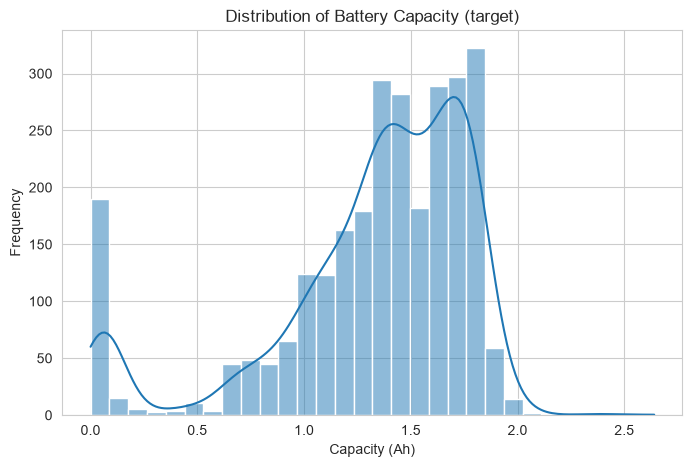

count    2769.000000
mean        1.326543
std         0.472517
min         0.000000
25%         1.150286
50%         1.428065
75%         1.673645
max         2.640149
Name: capacity, dtype: float64


In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(battery_df["capacity"].dropna(), bins=30, kde=True)
plt.title("Distribution of Battery Capacity (target)")
plt.xlabel("Capacity (Ah)")
plt.ylabel("Frequency")
plt.show()

print(battery_df["capacity"].describe())

### 2) Distribution plot for **each** feature

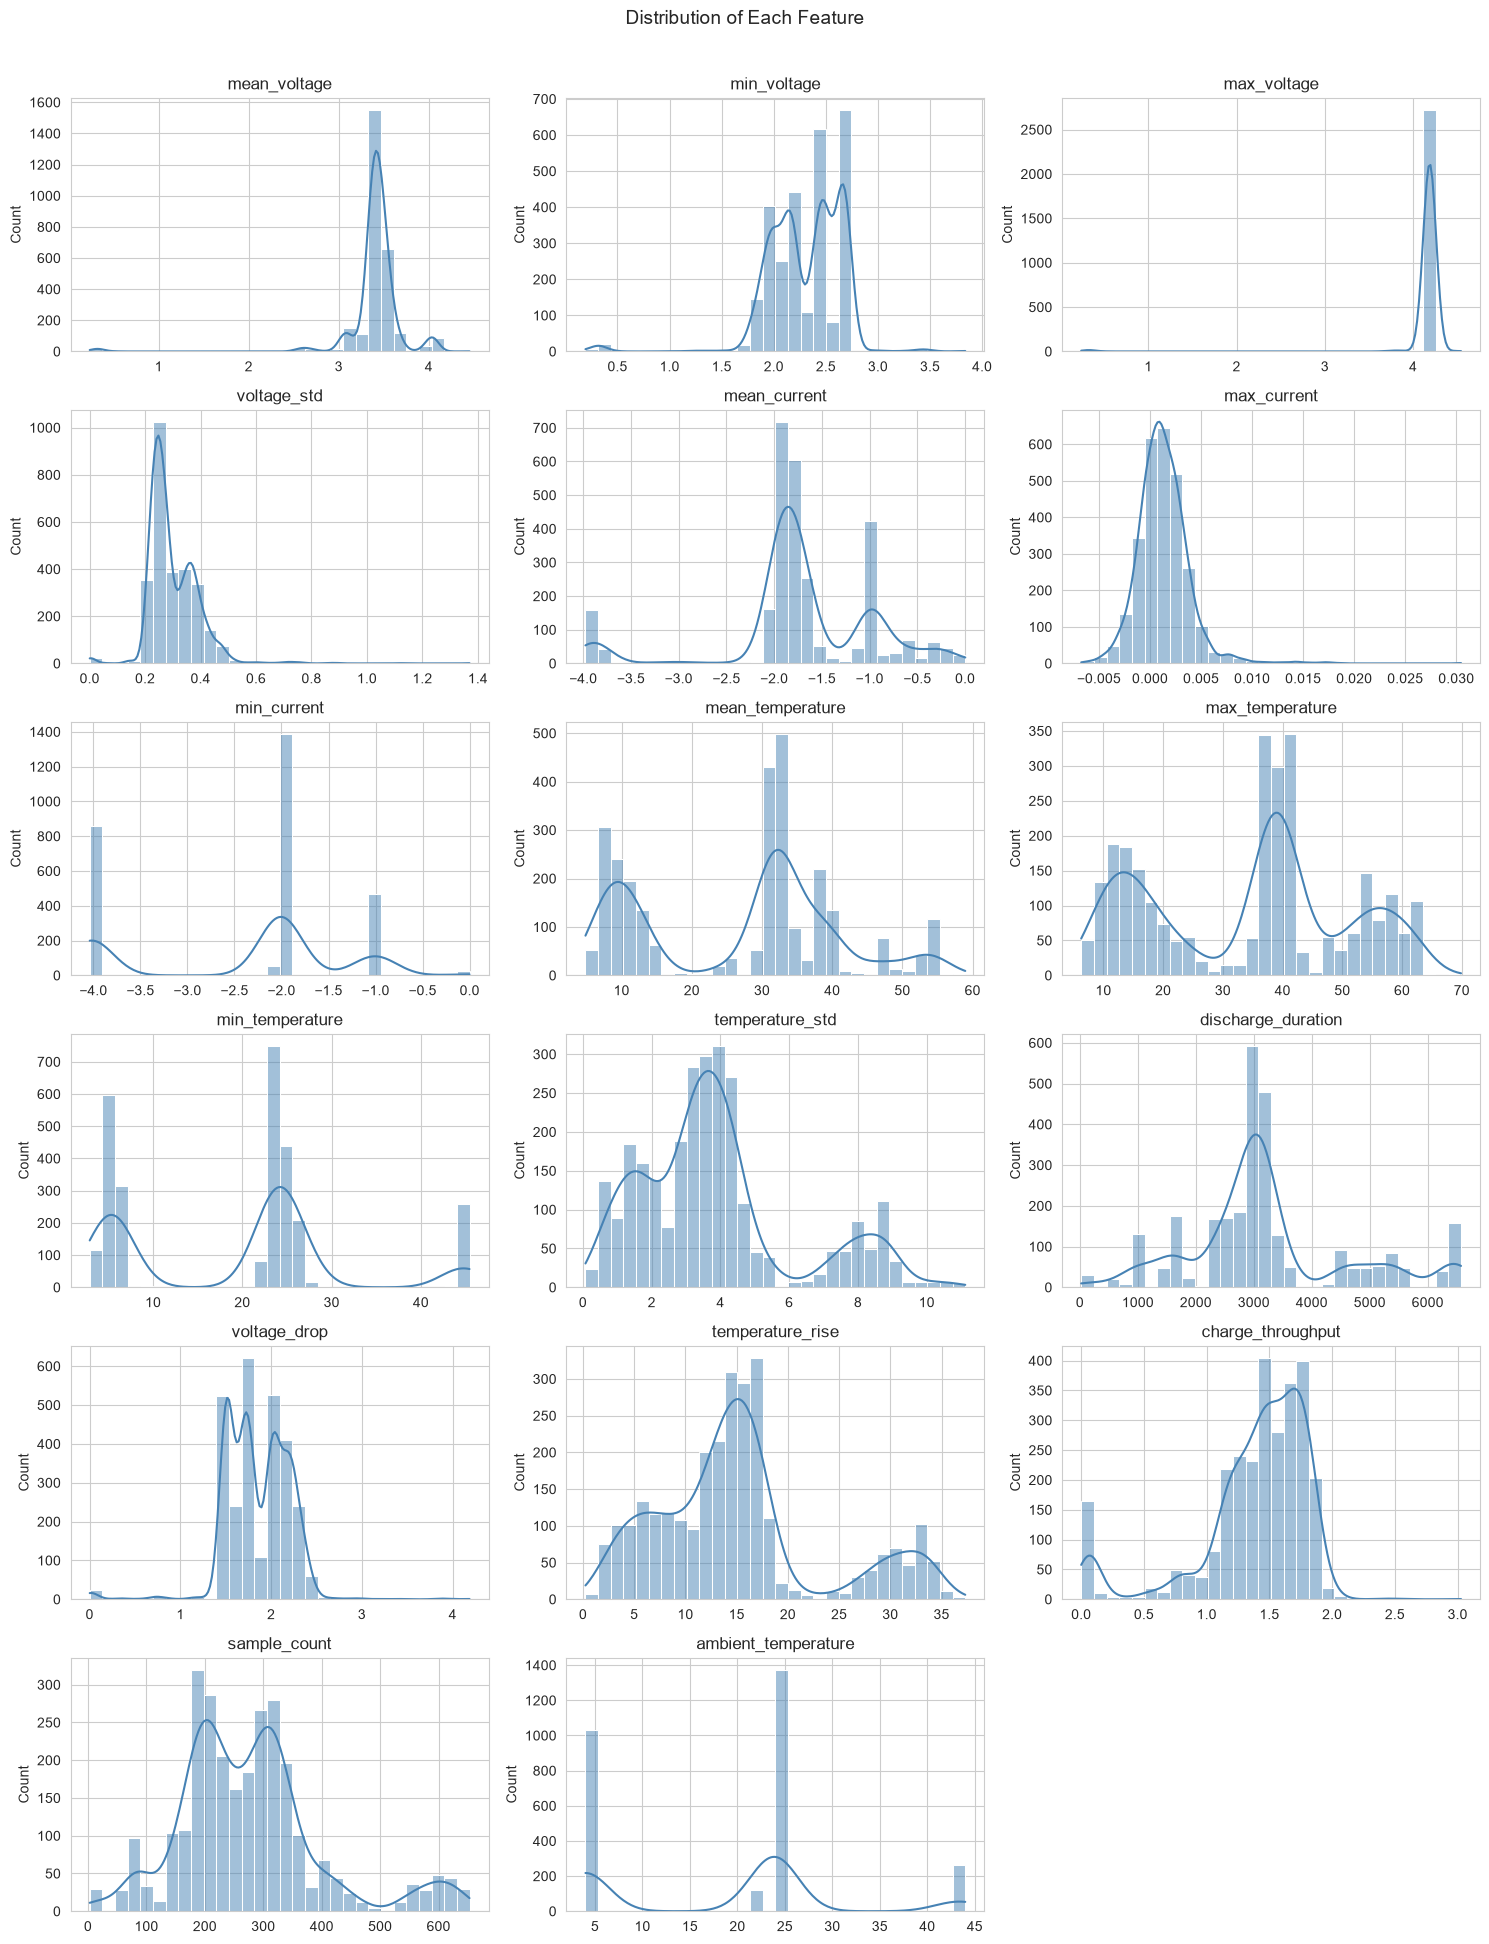

In [24]:
numeric_features = (
    battery_df
    .select_dtypes(include=np.number)
    .drop(columns=["capacity"], errors="ignore")
    .columns
    .tolist()
)

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes = np.array(axes).ravel()

for ax, feature in zip(axes, numeric_features):
    sns.histplot(battery_df[feature].dropna(), bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(feature)
    ax.set_xlabel("")

for ax in axes[len(numeric_features):]:
    ax.axis("off")

plt.suptitle("Distribution of Each Feature", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 3) Correlation heatmap

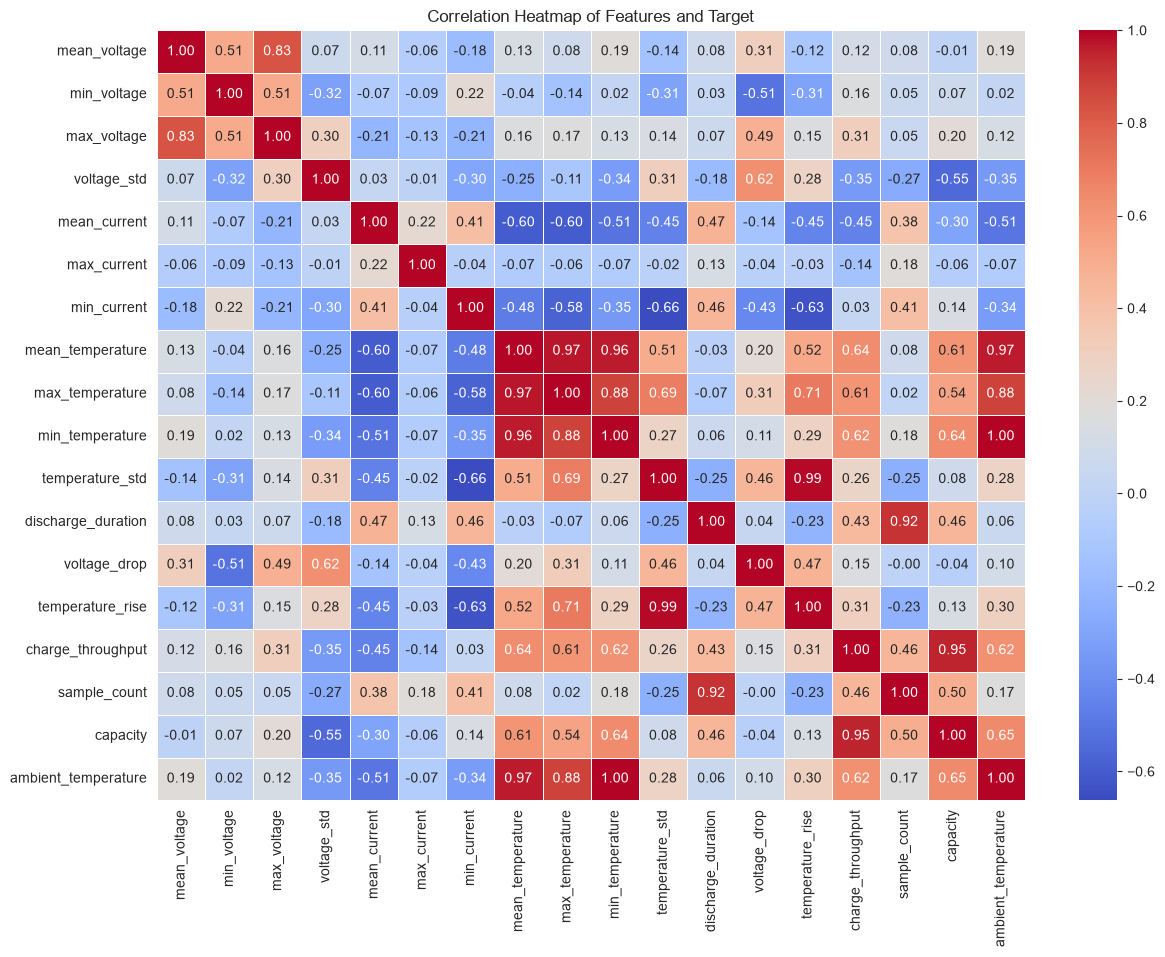

Correlation with target (capacity), strongest first:


,corr_with_capacity
charge_throughput,0.950868
ambient_temperature,0.648890
min_temperature,0.640755
mean_temperature,0.609803
voltage_std,-0.547447
max_temperature,0.542182
sample_count,0.496634
discharge_duration,0.455797
mean_current,-0.301811
max_voltage,0.195548


In [25]:
plt.figure(figsize=(14, 10))

correlation = battery_df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4)
plt.title("Correlation Heatmap of Features and Target")
plt.show()

print("Correlation with target (capacity), strongest first:")
display(
    correlation["capacity"]
    .drop("capacity")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("corr_with_capacity")
)

### 4) Feature-vs-target scatter plots

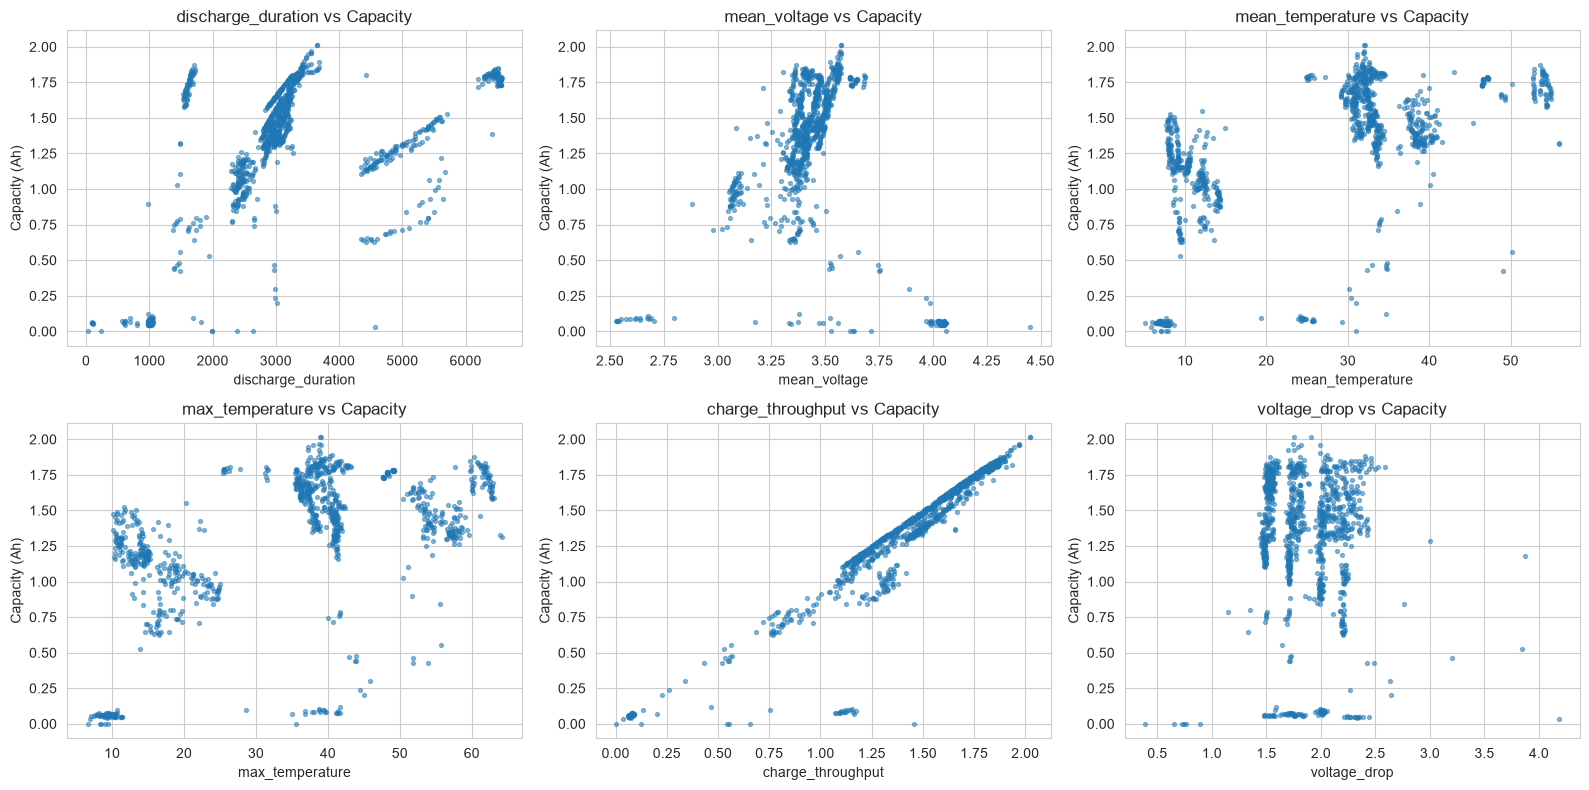

In [26]:
features_to_plot = [
    "discharge_duration",
    "mean_voltage",
    "mean_temperature",
    "max_temperature",
    "charge_throughput",
    "voltage_drop"
]
features_to_plot = [f for f in features_to_plot if f in battery_df.columns]

plot_data = battery_df.sample(n=min(1000, len(battery_df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, feature in zip(axes, features_to_plot):
    ax.scatter(plot_data[feature], plot_data["capacity"], s=8, alpha=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("Capacity (Ah)")
    ax.set_title(f"{feature} vs Capacity")

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 5) Capacity degradation over cycle life

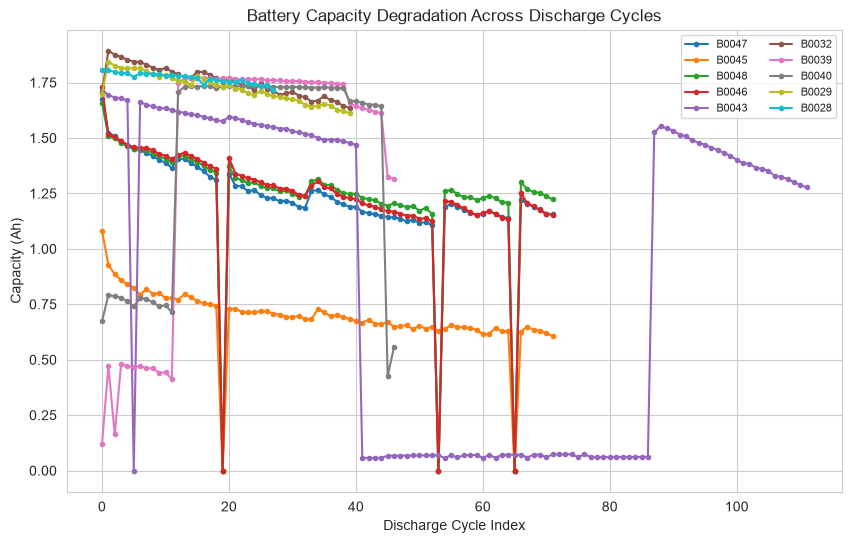

In [27]:
plt.figure(figsize=(10, 6))

for battery in discharge_data["battery_id"].unique()[:10]:
    battery_cycles = discharge_data[discharge_data["battery_id"] == battery]
    plt.plot(range(len(battery_cycles)), battery_cycles["Capacity"],
             marker="o", markersize=3, label=str(battery))

plt.title("Battery Capacity Degradation Across Discharge Cycles")
plt.xlabel("Discharge Cycle Index")
plt.ylabel("Capacity (Ah)")
plt.legend(ncol=2, fontsize=8)
plt.show()

---
#  Preprocessing & Feature Engineering

## Data cleaning

Three issues are handled explicitly:

1. **Duplicates**
2. **Missing values**
3. **Outliers** 

In [28]:
print("Rows before cleaning:", len(battery_df))

# 1. duplicates
duplicate_count = battery_df.duplicated().sum()
battery_df = battery_df.drop_duplicates()
print("Duplicate rows removed:", duplicate_count)

#  2. missing values 
battery_df["capacity"] = pd.to_numeric(battery_df["capacity"], errors="coerce")
battery_df = battery_df.dropna(subset=["capacity"])

numeric_columns = battery_df.select_dtypes(include=np.number).columns
battery_df[numeric_columns] = battery_df[numeric_columns].replace([np.inf, -np.inf], np.nan)

print("\nMissing values before imputation:")
print(battery_df[numeric_columns].isnull().sum()[lambda s: s > 0])

for column in numeric_columns:
    battery_df[column] = battery_df[column].fillna(battery_df[column].median())

print("\nTotal missing values after imputation:", int(battery_df.isnull().sum().sum()))
print("Rows after cleaning:", len(battery_df))

Rows before cleaning: 2794
Duplicate rows removed: 0

Missing values before imputation:
Series([], dtype: int64)

Total missing values after imputation: 0
Rows after cleaning: 2769


In [29]:
#  3. outlier DETECTION using the IQR rule 
feature_columns = [c for c in numeric_columns if c != "capacity"]

outlier_report = []

for column in feature_columns:
    q1 = battery_df[column].quantile(0.25)
    q3 = battery_df[column].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_out = int(((battery_df[column] < lower) | (battery_df[column] > upper)).sum())

    outlier_report.append({
        "Feature": column,
        "Lower fence": lower,
        "Upper fence": upper,
        "Outliers": n_out,
        "Outlier %": round(n_out / len(battery_df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("Outliers", ascending=False)
print("Outlier detection (IQR rule, 1.5 x IQR fences):")
display(outlier_df)

Outlier detection (IQR rule, 1.5 x IQR fences):


,Feature,Lower fence,Upper fence,Outliers,Outlier %
11,discharge_duration,1220.516000,4692.140000,651,23.51
0,mean_voltage,3.181015,3.678185,352,12.71
13,temperature_rise,-2.037378,28.699078,345,12.46
10,temperature_std,-1.100441,7.762959,322,11.63
4,mean_current,-3.268111,0.261995,206,7.44
15,sample_count,1.000000,521.000000,196,7.08
14,charge_throughput,0.555024,2.387384,175,6.32
2,max_voltage,4.158980,4.220329,121,4.37
5,max_current,-0.004410,0.006670,89,3.21
3,voltage_std,0.071666,0.527089,28,1.01


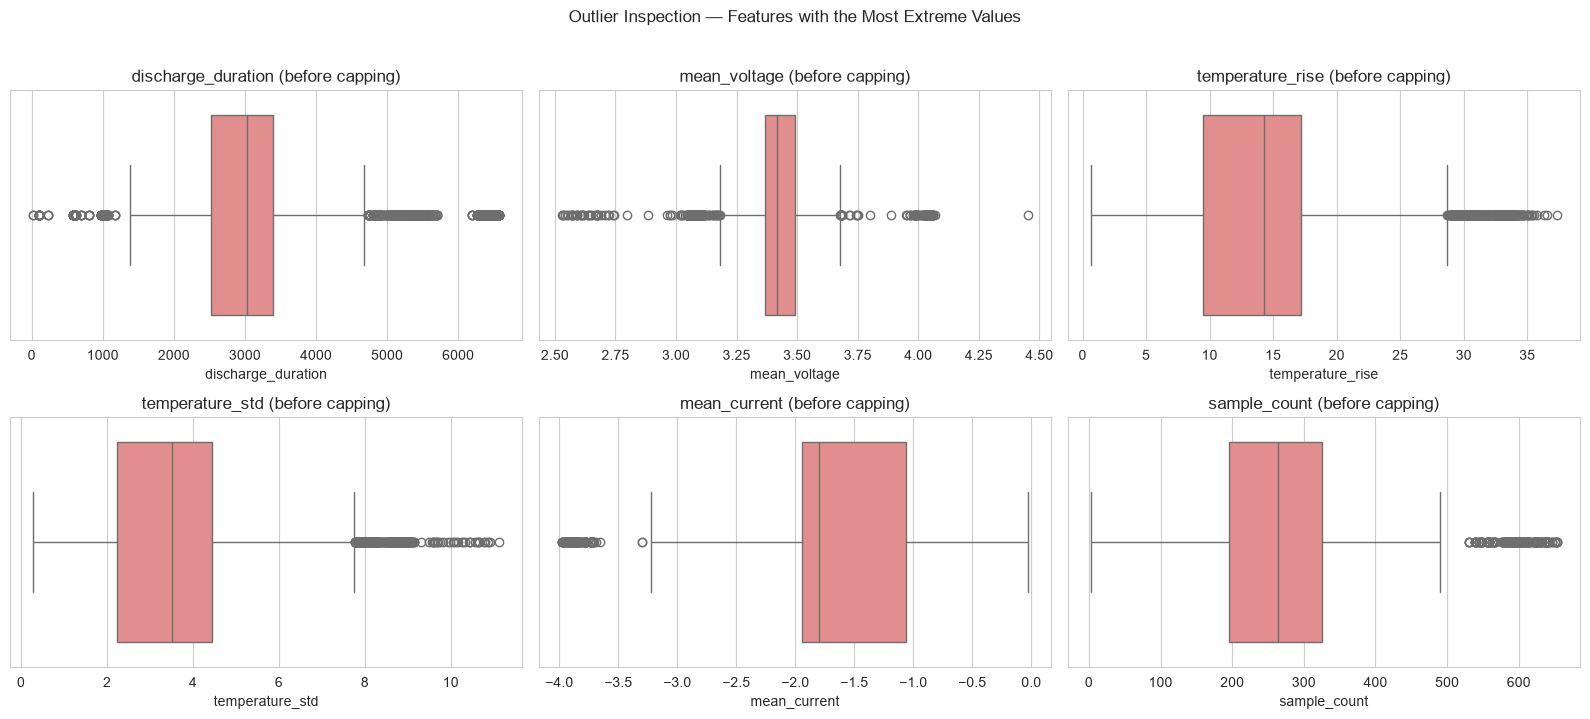

In [30]:
# Boxplots make the outliers visible before treatment
top_outlier_features = outlier_df.head(6)["Feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()

for ax, column in zip(axes, top_outlier_features):
    sns.boxplot(x=battery_df[column], ax=ax, color="lightcoral")
    ax.set_title(f"{column} (before capping)")

plt.suptitle("Outlier Inspection — Features with the Most Extreme Values", y=1.02)
plt.tight_layout()
plt.show()

Outlier capping applied to 17 features.


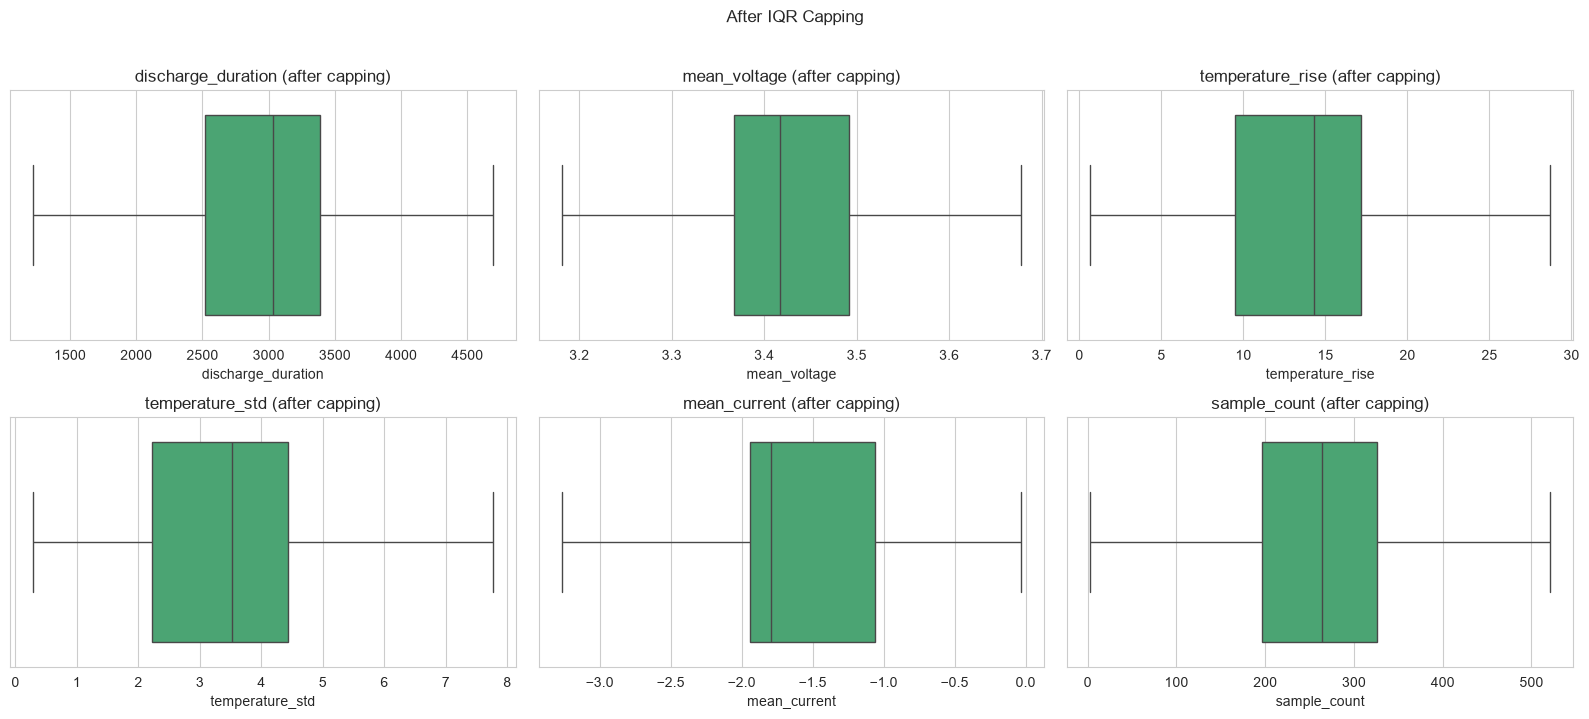


Cleaned dataset shape: (2769, 19)


,count,mean,std,min,25%,50%,75%,max
mean_voltage,2769.0,3.429150,0.115846,3.181015,3.367454,3.416749,3.491746,3.678185
min_voltage,2769.0,2.322654,0.299718,1.252439,2.074341,2.381871,2.622275,3.444177
max_voltage,2769.0,4.187760,0.011538,4.158980,4.181986,4.187096,4.197324,4.220329
voltage_std,2769.0,0.300027,0.074750,0.136462,0.242449,0.273872,0.356305,0.527089
mean_current,2769.0,-1.683634,0.664547,-3.268111,-1.944321,-1.796238,-1.061795,-0.029284
max_current,2769.0,0.001172,0.002150,-0.004410,-0.000255,0.001102,0.002515,0.006670
min_current,2769.0,-2.461739,1.104482,-4.038796,-3.992596,-2.014217,-1.993643,-0.996920
mean_temperature,2769.0,26.961265,13.879652,4.857764,11.647249,31.323263,34.276432,58.954811
max_temperature,2769.0,34.466999,16.333938,6.383481,17.275372,37.882588,42.718192,69.869746
min_temperature,2769.0,19.358910,12.112500,2.904756,5.751869,23.628173,24.660154,45.448270


In [31]:
# --- outlier TREATMENT: cap at the IQR fences (winsorising) ---
battery_clean = battery_df.copy()

for column in feature_columns:
    q1 = battery_clean[column].quantile(0.25)
    q3 = battery_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    battery_clean[column] = battery_clean[column].clip(lower=lower, upper=upper)

print("Outlier capping applied to", len(feature_columns), "features.")

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()

for ax, column in zip(axes, top_outlier_features):
    sns.boxplot(x=battery_clean[column], ax=ax, color="mediumseagreen")
    ax.set_title(f"{column} (after capping)")

plt.suptitle("After IQR Capping", y=1.02)
plt.tight_layout()
plt.show()

battery_df = battery_clean
print("\nCleaned dataset shape:", battery_df.shape)
display(battery_df.describe().T)

## Encoding, scaling and stratified splitting

### 1) Categorical encoding

In [32]:
categorical_columns = battery_df.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical columns detected:", categorical_columns)

if categorical_columns:
    for column in categorical_columns:
        encoder = LabelEncoder()
        battery_df[column + "_encoded"] = encoder.fit_transform(
            battery_df[column].astype(str)
        )
        print(f"  {column}: {battery_df[column].nunique()} unique values -> label encoded")
else:
    print("No categorical columns present — encoding not required.")

Categorical columns detected: ['battery_id']
  battery_id: 34 unique values -> label encoded


In [34]:
target = "capacity"

drop_columns = ["capacity", "battery_id", "battery_id_encoded"]

X = battery_df.drop(columns=drop_columns, errors="ignore")
X = X.select_dtypes(include=np.number)
y = pd.to_numeric(battery_df[target], errors="coerce")

# align, just in case any target value failed to convert
valid = y.notna()
X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)

feature_names = X.columns.tolist()

print("Features used:", len(feature_names))
print(feature_names)
print("\nX shape:", X.shape, "| y shape:", y.shape)

Features used: 17
['mean_voltage', 'min_voltage', 'max_voltage', 'voltage_std', 'mean_current', 'max_current', 'min_current', 'mean_temperature', 'max_temperature', 'min_temperature', 'temperature_std', 'discharge_duration', 'voltage_drop', 'temperature_rise', 'charge_throughput', 'sample_count', 'ambient_temperature']

X shape: (2769, 17) | y shape: (2769,)


### 2) Stratified train/test split

In [35]:
# Bin the continuous target into 5 quantile strata
y_strata = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_strata
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nStratum proportions (train vs test):")
comparison = pd.DataFrame({
    "train": pd.qcut(y_train, q=5, labels=False, duplicates="drop").value_counts(normalize=True).sort_index(),
    "test":  pd.qcut(y_test,  q=5, labels=False, duplicates="drop").value_counts(normalize=True).sort_index()
}).round(3)
display(comparison)

Training data: (2215, 17)
Testing data : (554, 17)

Stratum proportions (train vs test):


,train,test
capacity,,
0,0.2,0.200
1,0.2,0.200
2,0.2,0.199
3,0.2,0.200
4,0.2,0.200


### 3) Scaling


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled = scaler.transform(X_test)         # transform test with train statistics

print("Scaling completed (fitted on training set only).")
print("Train mean after scaling (should be ~0):", np.round(X_train_scaled.mean(), 6))
print("Train std  after scaling (should be ~1):", np.round(X_train_scaled.std(), 6))

Scaling completed (fitted on training set only).
Train mean after scaling (should be ~0): 0.0
Train std  after scaling (should be ~1): 1.0


##  Feature engineering — and why each feature should help

---
# Regression Track

## Implementation — 10 regression algorithms

All ten models are trained on the same scaled training split and evaluated on the same held-out
test split, so the comparison in C2 is fair.

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression (degree 2)
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (RBF)
10. K-Nearest Neighbours Regressor

In [37]:
regression_models = {
    "Linear Regression":     LinearRegression(),
    "Ridge Regression":      Ridge(alpha=1.0),
    "Lasso Regression":      Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet":            ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "Polynomial Regression": Pipeline([
                                 ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                                 ("linear", LinearRegression())
                             ]),
    "Decision Tree":         DecisionTreeRegressor(max_depth=10,random_state=RANDOM_STATE),
    "Random Forest":         RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":     GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,random_state=RANDOM_STATE),
    "Support Vector (SVR)":  SVR(kernel="rbf", C=10, gamma="scale"),
    "KNN Regressor":         KNeighborsRegressor(n_neighbors=5)
}

print("Models to train:", len(regression_models))
for name in regression_models:
    print(" -", name)

Models to train: 10
 - Linear Regression
 - Ridge Regression
 - Lasso Regression
 - ElasticNet
 - Polynomial Regression
 - Decision Tree
 - Random Forest
 - Gradient Boosting
 - Support Vector (SVR)
 - KNN Regressor


In [38]:
trained_models = {}
predictions = {}

for name, model in regression_models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    trained_models[name] = model
    predictions[name] = y_pred

    print(f"{name:<24} trained — predictions generated ({len(y_pred)} rows)")

print("\nAll 10 regression models trained successfully with no errors.")

Linear Regression        trained — predictions generated (554 rows)
Ridge Regression         trained — predictions generated (554 rows)
Lasso Regression         trained — predictions generated (554 rows)
ElasticNet               trained — predictions generated (554 rows)
Polynomial Regression    trained — predictions generated (554 rows)
Decision Tree            trained — predictions generated (554 rows)
Random Forest            trained — predictions generated (554 rows)
Gradient Boosting        trained — predictions generated (554 rows)
Support Vector (SVR)     trained — predictions generated (554 rows)
KNN Regressor            trained — predictions generated (554 rows)

All 10 regression models trained successfully with no errors.


## Comparative evaluation — single summary table

R², RMSE and MAE are computed for **all 10 models on the same test split** and ranked by R².

In [39]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


results = [evaluate_model(name, y_test, pred) for name, pred in predictions.items()]

results_df = (
    pd.DataFrame(results)
    .sort_values(by="R²", ascending=False)
    .reset_index(drop=True)
)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

print("Regression model comparison (same test split, ranked by R²):")
display(results_df.round(4))

Regression model comparison (same test split, ranked by R²):


,Model,R²,RMSE,MAE
Rank,,,,
1,Gradient Boosting,0.9968,0.0256,0.0136
2,Random Forest,0.9960,0.0289,0.0096
3,Decision Tree,0.9901,0.0452,0.0151
4,Support Vector (SVR),0.9755,0.0712,0.0505
5,KNN Regressor,0.9696,0.0793,0.0310
6,Polynomial Regression,0.9658,0.0840,0.0312
7,Ridge Regression,0.9312,0.1193,0.0653
8,Linear Regression,0.9310,0.1194,0.0664
9,ElasticNet,0.9273,0.1226,0.0640


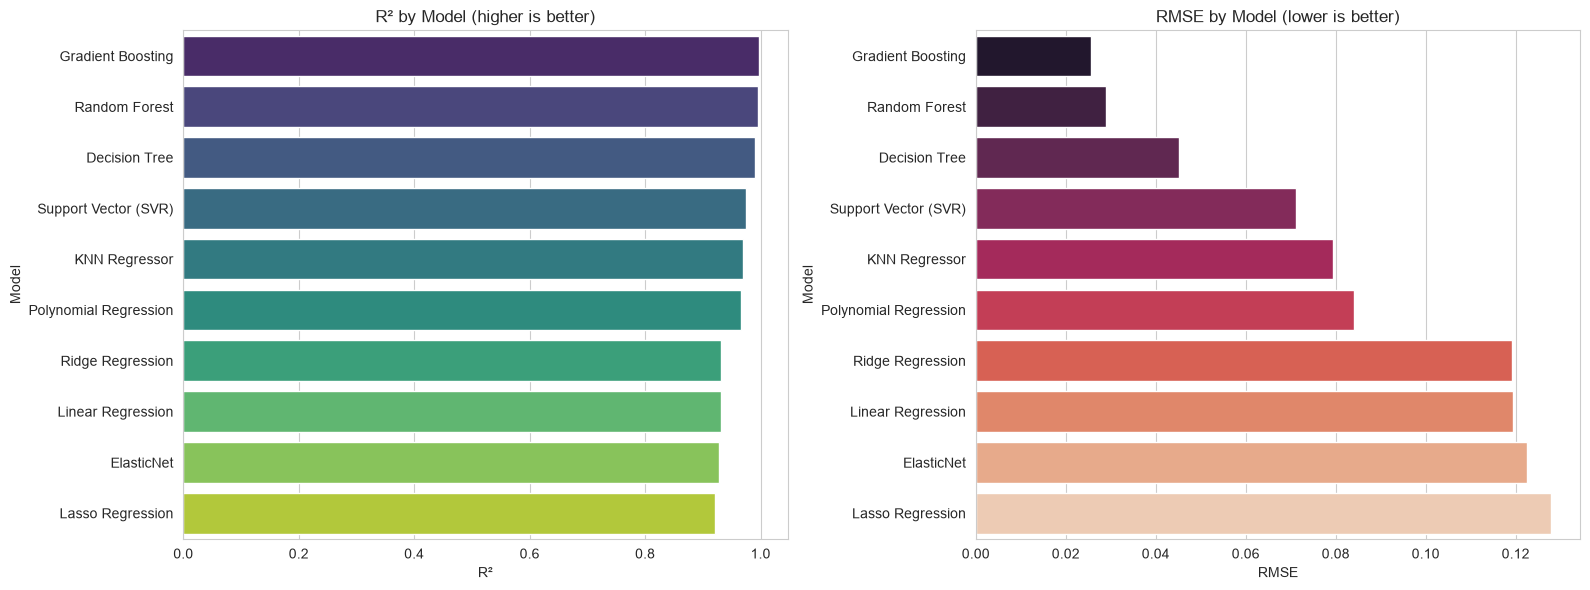

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=results_df, x="R²", y="Model", ax=axes[0], palette="viridis")
axes[0].set_title("R² by Model (higher is better)")

sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[1], palette="rocket")
axes[1].set_title("RMSE by Model (lower is better)")

plt.tight_layout()
plt.show()

In [41]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model by R²:", best_model_name)
print(results_df.head(1)[["R²", "RMSE", "MAE"]].round(4).to_string(index=False))

Best model by R²: Gradient Boosting
    R²   RMSE    MAE
0.9968 0.0256 0.0136


##  Hyperparameter tuning


In [ ]:
# Tuning 1: Random Forest (GridSearchCV)
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

print("\nRandom Forest — best parameters:", rf_grid.best_params_)
print("Random Forest — best CV R²:", round(rf_grid.best_score_, 4))

In [ ]:
#  Tuning 2: Ridge (GridSearchCV) 
ridge_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 500.0]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

print("Ridge — best parameters:", ridge_grid.best_params_)
print("Ridge — best CV R²:", round(ridge_grid.best_score_, 4))

In [33]:
# Tuning 3: Gradient Boosting (RandomizedSearchCV)
gb_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=gb_param_dist,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_search.fit(X_train_scaled, y_train)

print("Gradient Boosting — best parameters:", gb_search.best_params_)
print("Gradient Boosting — best CV R²:", round(gb_search.best_score_, 4))

Gradient Boosting — best parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Gradient Boosting — best CV R²: 0.9952


In [34]:
#  Before vs after tuning on the SAME test split
tuning_rows = []

tuned_models = {
    "Random Forest":     rf_grid.best_estimator_,
    "Ridge Regression":  ridge_grid.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_
}

best_params_map = {
    "Random Forest":     rf_grid.best_params_,
    "Ridge Regression":  ridge_grid.best_params_,
    "Gradient Boosting": gb_search.best_params_
}

for name, tuned in tuned_models.items():

    base_pred = predictions[name]
    tuned_pred = tuned.predict(X_test_scaled)

    base_r2, tuned_r2 = r2_score(y_test, base_pred), r2_score(y_test, tuned_pred)
    base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))
    tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))

    tuning_rows.append({
        "Model": name,
        "Best Parameters": str(best_params_map[name]),
        "R² (default)": base_r2,
        "R² (tuned)": tuned_r2,
        "R² improvement": tuned_r2 - base_r2,
        "RMSE (default)": base_rmse,
        "RMSE (tuned)": tuned_rmse,
        "RMSE improvement": base_rmse - tuned_rmse
    })

    # keep the tuned version available for the final comparison
    predictions[name + " (tuned)"] = tuned_pred
    trained_models[name + " (tuned)"] = tuned

tuning_df = pd.DataFrame(tuning_rows)

print("Hyperparameter tuning — before vs after (test set):")
display(tuning_df.round(4))

Hyperparameter tuning — before vs after (test set):


,Model,Best Parameters,R² (default),R² (tuned),R² improvement,RMSE (default),RMSE (tuned),RMSE improvement
0,Random Forest,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_...",0.9960,0.9960,0.0000,0.0289,0.0289,0.0000
1,Ridge Regression,{'alpha': 0.1},0.9312,0.9311,-0.0001,0.1193,0.1194,-0.0001
2,Gradient Boosting,"{'subsample': 1.0, 'n_estimators': 100, 'max_d...",0.9968,0.9984,0.0015,0.0256,0.0183,0.0073


In [35]:
final_results = [evaluate_model(name, y_test, pred) for name, pred in predictions.items()]

final_results_df = (
    pd.DataFrame(final_results)
    .sort_values(by="R²", ascending=False)
    .reset_index(drop=True)
)
final_results_df.index = final_results_df.index + 1
final_results_df.index.name = "Rank"

print("Final leaderboard including tuned models:")
display(final_results_df.round(4))

best_model_name = final_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("\nOverall best model:", best_model_name)

Final leaderboard including tuned models:


,Model,R²,RMSE,MAE
Rank,,,,
1,Gradient Boosting (tuned),0.9984,0.0183,0.0105
2,Gradient Boosting,0.9968,0.0256,0.0136
3,Random Forest (tuned),0.9960,0.0289,0.0096
4,Random Forest,0.9960,0.0289,0.0096
5,Decision Tree,0.9959,0.0290,0.0124
6,Support Vector (SVR),0.9755,0.0712,0.0505
7,KNN Regressor,0.9696,0.0793,0.0310
8,Polynomial Regression,0.9658,0.0840,0.0312
9,Ridge Regression,0.9312,0.1193,0.0653



Overall best model: Gradient Boosting (tuned)


##  Visualisation of the best model

### 1) Predicted vs actual

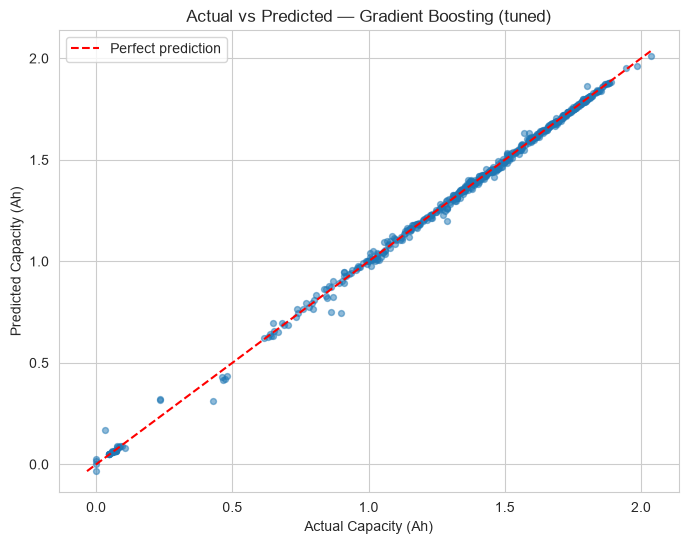

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_predictions, alpha=0.5, s=18)

min_value = float(min(y_test.min(), np.min(best_predictions)))
max_value = float(max(y_test.max(), np.max(best_predictions)))
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="red",
         label="Perfect prediction")

plt.xlabel("Actual Capacity (Ah)")
plt.ylabel("Predicted Capacity (Ah)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.legend()
plt.show()

### 2) Residual plot

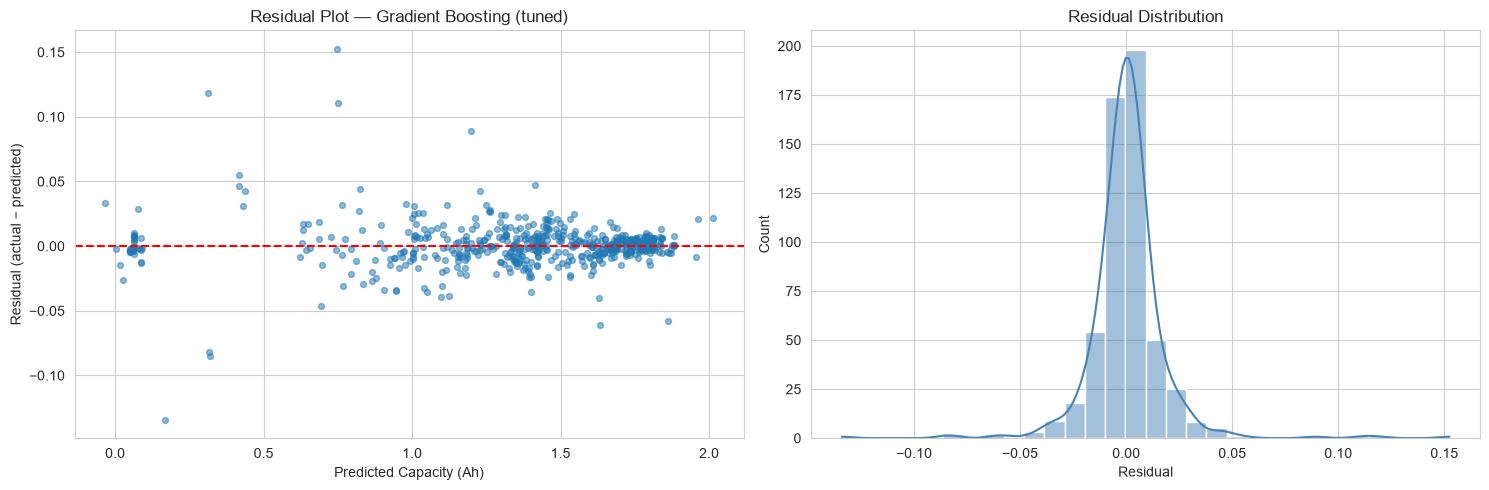

Residual mean: 0.00052
Residual std : 0.0183


In [37]:
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(best_predictions, residuals, alpha=0.5, s=18)
axes[0].axhline(y=0, linestyle="--", color="red")
axes[0].set_xlabel("Predicted Capacity (Ah)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title(f"Residual Plot — {best_model_name}")

sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color="steelblue")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print("Residual mean:", round(float(residuals.mean()), 5))
print("Residual std :", round(float(residuals.std()), 5))

### 3)Feature importance (tree-based model)

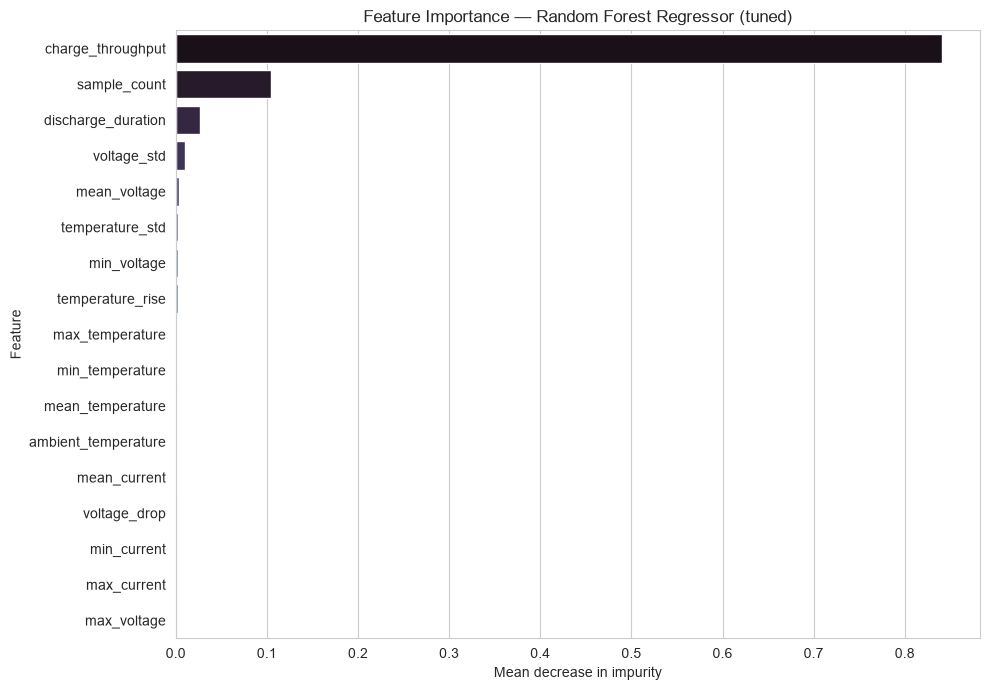

,Feature,Importance
0,charge_throughput,0.8405
1,sample_count,0.1047
2,discharge_duration,0.0269
3,voltage_std,0.0098
4,mean_voltage,0.0040
5,temperature_std,0.0028
6,min_voltage,0.0023
7,temperature_rise,0.0019
8,max_temperature,0.0015
9,min_temperature,0.0011


In [38]:
importance_model = tuned_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="mako")
plt.title("Feature Importance — Random Forest Regressor (tuned)")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

display(importance_df.round(4))

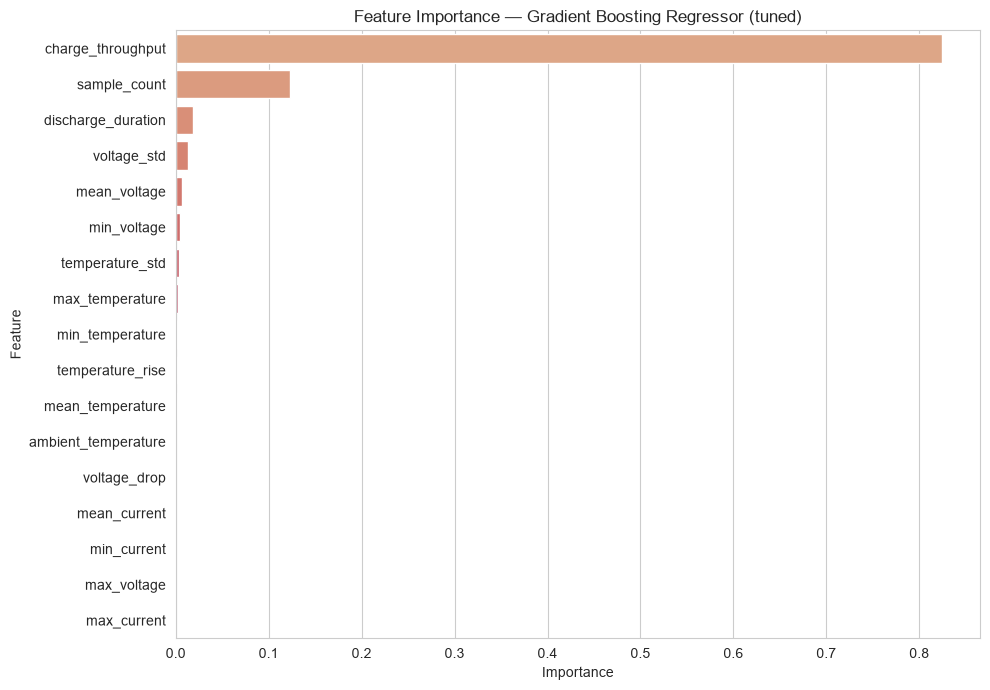

In [39]:
# Second tree-based view: Gradient Boosting importances, for cross-checking
gb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tuned_models["Gradient Boosting"].feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=gb_importance_df, x="Importance", y="Feature", palette="flare")
plt.title("Feature Importance — Gradient Boosting Regressor (tuned)")
plt.tight_layout()
plt.show()

---
# Conclusion & Narrative Summary

In [22]:
print("============================================================================")
print("FINAL SUMMARY")
print("============================================================================")
print("Dataset rows used        :", len(battery_df))
print("Features engineered      :", len(feature_names))
print("Regression models trained:", len(regression_models), "(+3 tuned variants)")
print("Best regression model    :", best_model_name)
print("   R²   :", round(float(final_results_df.iloc[0]["R²"]), 4))
print("   RMSE :", round(float(final_results_df.iloc[0]["RMSE"]), 4))
print("   MAE  :", round(float(final_results_df.iloc[0]["MAE"]), 4))
print("Task type                : Regression (continuous target)")
print("============================================================================")

FINAL SUMMARY
Dataset rows used        : 2794


NameError: name 'feature_names' is not defined